<a href="https://colab.research.google.com/github/asala-ai/Sales-Analytics-Dashboard/blob/main/02_Sales_Analytics_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Analytics Dashboard

## Project Overview

This project analyzes sales data to discover business insights using Python, Pandas, and Data Visualization techniques.

The analysis focuses on understanding revenue performance, profitability, customer behavior, regional performance, and sales trends.

## Objectives

- Analyze sales performance.
- Identify profitable categories and products.
- Understand customer segments and behavior.
- Discover seasonal sales patterns.
- Extract actionable business insights from data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

path = kagglehub.dataset_download("binib1997/superstore")

df = pd.read_csv(
    path + "/Superstore.csv",
    encoding="latin1"
)

df.head()

Using Colab cache for faster access to the 'superstore' dataset.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# 4. Data Understanding & Preparation

This section examines the dataset structure and data quality before performing analysis.

In [3]:
df.shape

(9994, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# 5. Feature Engineering

This section creates additional time-based features from order dates to support sales trend and seasonality analysis.

In [9]:
# Create time-based features

df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month Name"] = df["Order Date"].dt.month_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October


# 6. KPI Summary

This section presents the main business performance indicators extracted from the dataset.

The KPIs provide a quick overview of revenue, profitability, customer activity, and overall business performance.

In [10]:
# Calculate main business KPIs

total_sales = df["Sales"].sum()

total_profit = df["Profit"].sum()

profit_margin = (total_profit / total_sales) * 100

total_orders = df["Order ID"].nunique()

total_customers = df["Customer ID"].nunique()


kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Profit Margin",
        "Total Orders",
        "Total Customers"
    ],
    "Value": [
        round(total_sales,2),
        round(total_profit,2),
        round(profit_margin,2),
        total_orders,
        total_customers
    ]
})

kpi_summary

,Metric,Value
0,Total Sales,2297200.86
1,Total Profit,286397.02
2,Profit Margin,12.47
3,Total Orders,5009.00
4,Total Customers,793.00


## KPI Insights

The dataset analysis shows the following overall business performance:

- Total sales reached approximately $2.30M.
- Total profit reached approximately $286K with an overall profit margin of 12.47%.
- The business processed 5,009 unique orders and served 793 customers.

These KPIs provide a high-level overview of revenue generation, profitability, and customer reach.

# 7. Exploratory Analysis

This section explores the sales dataset to identify business patterns, revenue drivers, profitability factors, customer behavior, and regional performance.

The analysis covers:

- Sales Performance
- Profitability Analysis
- Customer Analysis
- Regional Analysis
- Correlation Analysis

In [11]:
# Prepare basic analysis variables

category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)


year_sales = (
    df.groupby("Year")["Sales"]
    .sum()
)


monthly_sales = (
    df.groupby(["Month", "Month Name"])["Sales"]
    .sum()
)


category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


## 7.1 Sales Performance

This section analyzes sales performance across categories and time periods to identify the main revenue contributors and sales trends.

### Sales by Category

This analysis identifies which product categories contribute the most to overall revenue.

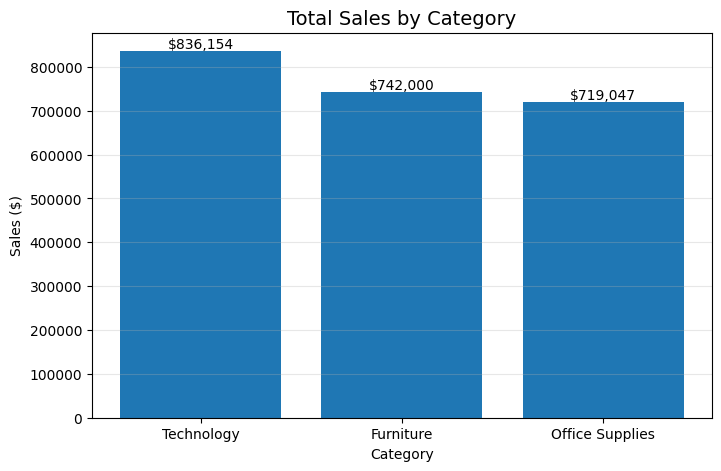

In [12]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Total Sales by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Sales ($)")


for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )


plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.show()

### Insight

- Technology generated the highest sales value, making it the strongest revenue contributor.
- Furniture achieved high sales volume but requires further profitability investigation.
- Office Supplies generated lower sales compared with Technology but showed strong profit efficiency.

### Annual Sales Growth Analysis

This analysis examines yearly sales performance to identify growth trends and business expansion over time.

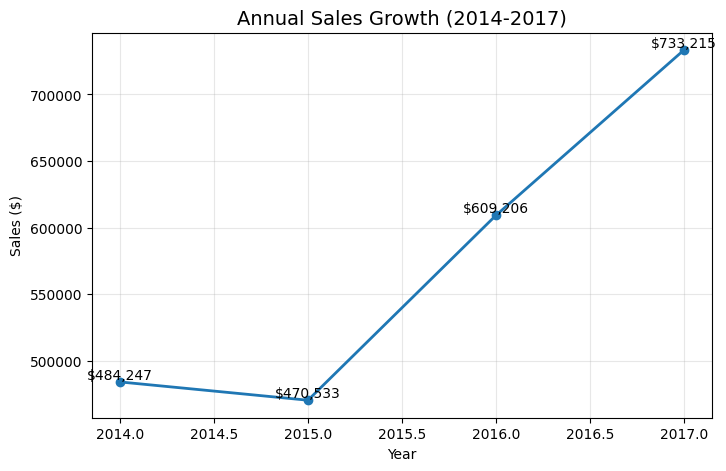

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    year_sales.index,
    year_sales.values,
    marker="o",
    linewidth=2
)


plt.title("Annual Sales Growth (2014-2017)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Sales ($)")


for x, y in zip(year_sales.index, year_sales.values):

    plt.text(
        x,
        y,
        f"${y:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )


plt.grid(alpha=0.3)

plt.show()

### Insight

- Sales showed a positive growth trend between 2014 and 2017.
- The highest sales performance was achieved in 2017 with revenue exceeding $733K.
- The continuous growth indicates business expansion over the analyzed period.

### Monthly Sales Seasonality Analysis

This analysis identifies monthly sales patterns and highlights peak demand periods throughout the year.

Understanding seasonality helps businesses optimize inventory planning and marketing campaigns.

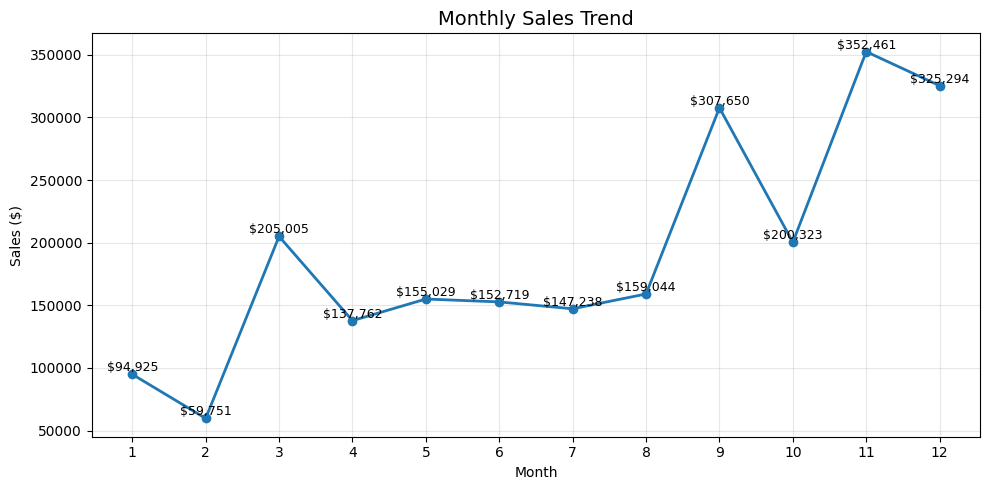

In [14]:
plt.figure(figsize=(10,5))


plt.plot(
    monthly_sales.index.get_level_values("Month"),
    monthly_sales.values,
    marker="o",
    linewidth=2
)


plt.title("Monthly Sales Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Sales ($)")


for x, y in zip(
    monthly_sales.index.get_level_values("Month"),
    monthly_sales.values
):

    plt.text(
        x,
        y,
        f"${y:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )


plt.xticks(
    range(1,13)
)


plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

- Sales demonstrate clear seasonal patterns throughout the year.
- November and December recorded the highest sales performance, indicating strong end-of-year demand.
- The company should prepare inventory and marketing strategies before peak sales periods.

In [ ]:
## 7.2 Profitability Analysis

This section evaluates business profitability by analyzing profit margins and identifying products that negatively impact overall performance.

The analysis helps understand which categories generate efficient profits and which products require improvement.

## 7.2 Profitability Analysis

This section evaluates business profitability by analyzing profit margins and identifying products that negatively impact overall performance.

The analysis helps understand which categories generate efficient profits and which products require improvement.

### Profit Margin Analysis

Profit margin measures business efficiency by showing how much profit is generated from each dollar of sales.

This analysis identifies categories with strong profitability and categories that require further investigation.

In [15]:
# Calculate profit margin by category

category_profit = (
    df.groupby("Category")[["Sales", "Profit"]]
    .sum()
)


category_profit["Profit Margin %"] = (
    category_profit["Profit"] /
    category_profit["Sales"] * 100
)


category_profit = (
    category_profit
    .sort_values(
        "Profit Margin %",
        ascending=False
    )
)


category_profit

,Sales,Profit,Profit Margin %
Category,,,
Technology,836154.0330,145454.9481,17.395712
Office Supplies,719047.0320,122490.8008,17.035158
Furniture,741999.7953,18451.2728,2.486695


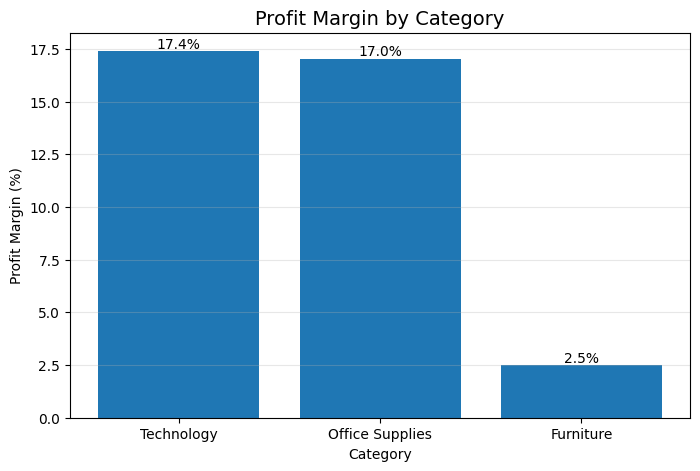

In [16]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    category_profit.index,
    category_profit["Profit Margin %"]
)


plt.title(
    "Profit Margin by Category",
    fontsize=14
)

plt.xlabel("Category")

plt.ylabel("Profit Margin (%)")


for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )


plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

### Insight

- Technology achieved the highest profit margin, combining strong revenue with high profitability.
- Office Supplies showed efficient profit generation.
- Furniture generated high sales volume but had a significantly lower profit margin, indicating possible pricing, discount, or cost issues.

### Loss-Making Products Analysis

This analysis identifies products that generated negative profit.

Understanding loss-making products helps businesses review pricing strategies, discount policies, and operational costs.

In [17]:
# Identify top 10 loss-making products

loss_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=True)
    .head(10)
)


loss_products

,Profit
Product Name,
Cubify CubeX 3D Printer Double Head Print,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156
Bush Advantage Collection Racetrack Conference Table,-1934.3976
GBC DocuBind P400 Electric Binding System,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,-1299.1836
Balt Solid Wood Round Tables,-1201.0581


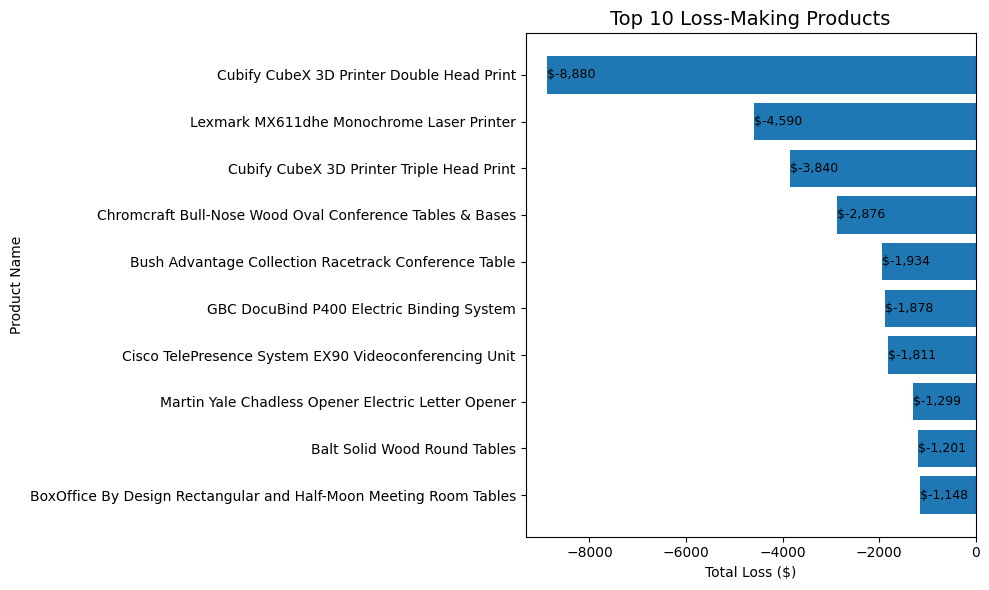

In [18]:
plt.figure(figsize=(10,6))


bars = plt.barh(
    loss_products.index,
    loss_products.values
)


plt.title(
    "Top 10 Loss-Making Products",
    fontsize=14
)

plt.xlabel("Total Loss ($)")

plt.ylabel("Product Name")


for bar in bars:

    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"${width:,.0f}",
        va="center",
        fontsize=9
    )


plt.gca().invert_yaxis()


plt.tight_layout()

plt.show()

### Insight

- Some products generated significant losses despite having high sales potential.
- The largest losses were associated with specific products that require further review.
- Loss-making products should be evaluated through pricing strategies, discount levels, and cost optimization.

## 7.3 Customer Analysis

This section analyzes customer segments to understand which groups contribute the most to sales and profitability.

The analysis helps identify the most valuable customer segments and supports better customer targeting strategies.

In [19]:
# Calculate sales and profit by customer segment

segment_analysis = (
    df.groupby("Segment")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

segment_analysis

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


### Sales by Customer Segment

This analysis compares total sales across customer segments to identify the largest contributors to revenue.

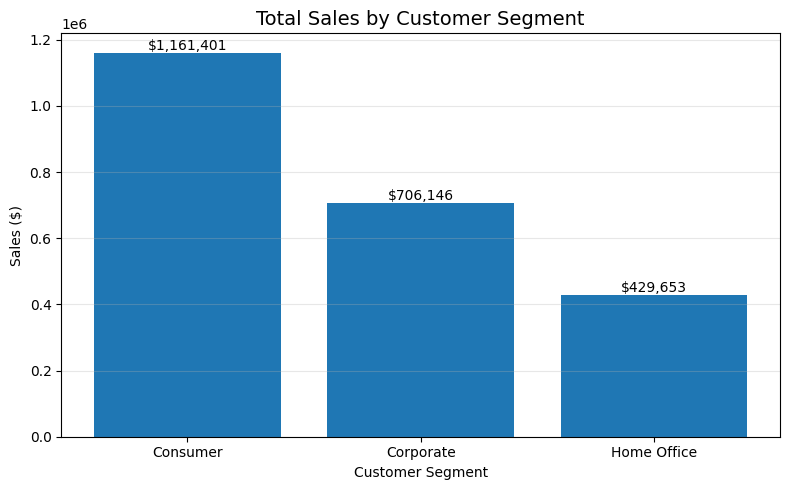

In [20]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    segment_analysis.index,
    segment_analysis["Sales"]
)

plt.title("Total Sales by Customer Segment", fontsize=14)
plt.xlabel("Customer Segment")
plt.ylabel("Sales ($)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

- Consumer customers generated the highest total sales, making them the largest revenue-contributing segment.
- Corporate customers represented the second-largest contributor to sales.
- Home Office customers generated the lowest sales among the three segments.

### Profit by Customer Segment

This analysis compares total profit across customer segments to determine which customer groups contribute the most to overall profitability.

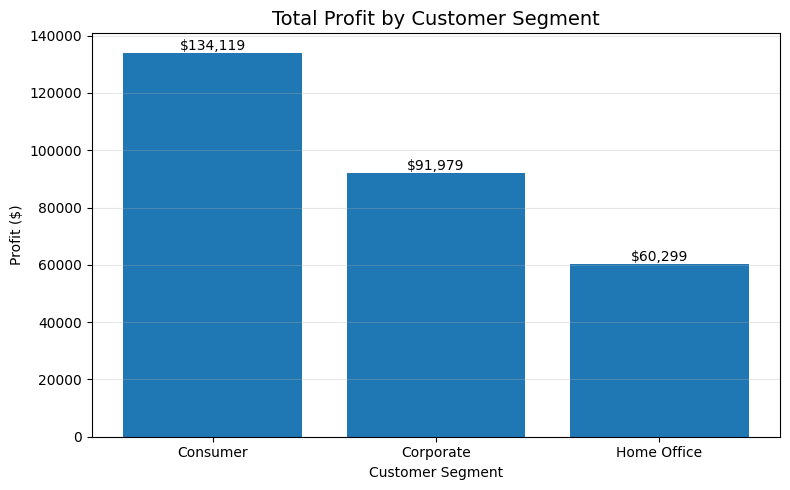

In [21]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    segment_analysis.index,
    segment_analysis["Profit"]
)

plt.title("Total Profit by Customer Segment", fontsize=14)
plt.xlabel("Customer Segment")
plt.ylabel("Profit ($)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

- Consumer customers generated the highest total profit.
- Corporate customers were the second-largest contributor to profitability.
- Home Office generated lower profit compared with the other segments but remained profitable.
- Consumer customers represent the most important segment in terms of both revenue and total profit.

## 7.4 Regional Analysis

This section evaluates sales and profitability across different regions.

Understanding regional performance helps businesses identify strong markets and areas that require improvement.

In [22]:
# Calculate sales and profit by region

region_analysis = (
    df.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

region_analysis

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


### Sales by Region

This analysis compares total sales across different regions to identify the strongest revenue-generating markets.

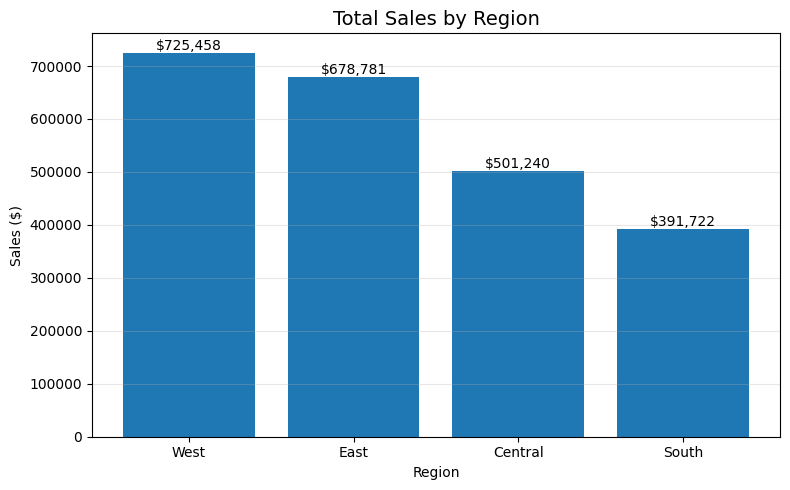

In [23]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    region_analysis.index,
    region_analysis["Sales"]
)

plt.title("Total Sales by Region", fontsize=14)

plt.xlabel("Region")

plt.ylabel("Sales ($)")


for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )


plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

- West region generated the highest sales value among all regions.
- East region also showed strong revenue performance.
- South region recorded the lowest sales contribution, indicating potential opportunities for market improvement.

### Profit by Region

This analysis compares profitability across regions to identify the most efficient markets.

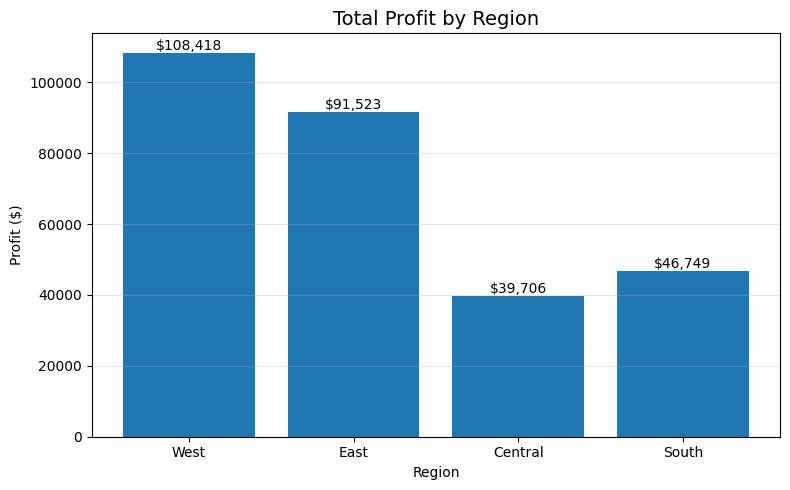

In [24]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    region_analysis.index,
    region_analysis["Profit"]
)

plt.title("Total Profit by Region", fontsize=14)

plt.xlabel("Region")

plt.ylabel("Profit ($)")


for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )


plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

- West region achieved the highest profit performance.
- East region also demonstrated strong profitability.
- Regional differences indicate the importance of optimizing marketing strategies and resource allocation based on market performance.

## 7.5 Correlation Analysis

Correlation analysis helps identify relationships between numerical variables.

This analysis shows how variables such as sales, profit, quantity, and discount are related to each other.

In [25]:
# Calculate correlation matrix

correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Year,Month
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497,0.015430,-0.018732
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961,0.004299,0.026234
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064,-0.009679,-0.000625
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253,-0.005810,0.023355
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487,-0.002662,-0.004935
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000,0.004670,-0.000502
Year,0.015430,0.004299,-0.009679,-0.005810,-0.002662,0.004670,1.000000,-0.020183
Month,-0.018732,0.026234,-0.000625,0.023355,-0.004935,-0.000502,-0.020183,1.000000


### Correlation Heatmap

A heatmap visualization is used to make relationships between numerical variables easier to understand.

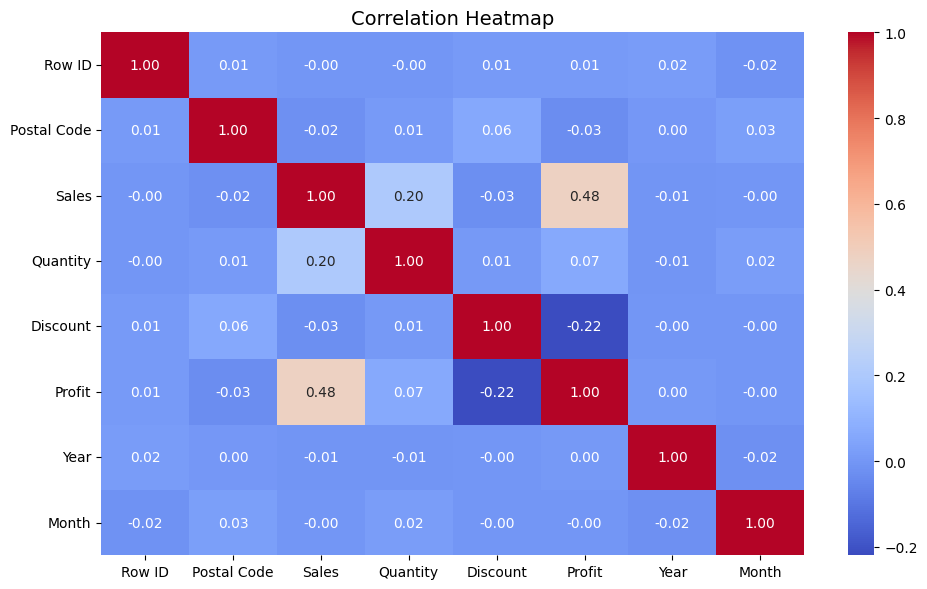

In [26]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap",
    fontsize=14
)

plt.tight_layout()

plt.show()

### Insight

- Sales and Profit show a positive relationship, indicating that higher sales generally contribute to higher profits.

- Discount has a negative relationship with Profit, suggesting that excessive discounts may reduce profitability.

- Quantity has a weaker relationship with Profit, indicating that selling more units does not always guarantee higher profit.

- Product selection and pricing strategy are important factors affecting profitability.

# 8. Final Insights

This section summarizes the main findings discovered from the exploratory analysis and highlights the key business insights derived from the sales data.

## Key Business Insights

### 1. Category Performance

- Technology was the strongest category, achieving the highest sales value and highest profit margin.
- Office Supplies showed strong profitability despite generating lower sales compared with Technology.
- Furniture generated high sales volume but had a significantly lower profit margin, indicating potential pricing, discount, or cost issues.


### 2. Sales Growth Over Time

- Sales showed a positive growth trend between 2014 and 2017.
- The highest annual sales performance was achieved in 2017 with revenue exceeding $733K.
- The continuous growth indicates business expansion and improved market performance.


### 3. Seasonal Sales Patterns

- Sales demonstrated clear seasonal variations throughout the year.
- November and December recorded the highest sales levels.
- The company should prepare inventory and marketing strategies before peak demand periods.


### 4. Customer Segment Performance

- Consumer customers were the largest contributors to both sales and profit.
- Corporate customers represented an important profitable segment.
- Home Office customers generated lower revenue but maintained positive profitability.


### 5. Regional Performance

- West region achieved the highest sales and profit performance.
- East region also demonstrated strong revenue generation and profitability.
- Regional differences highlight opportunities for improving market strategies.


### 6. Product Performance

- Several Technology products were among the strongest contributors to sales and profit.
- Some products generated significant losses despite having sales potential.
- Loss-making products require further evaluation of pricing, discounts, and operational costs.

# 9. Business Recommendations

Based on the analysis results, the following recommendations are suggested:

- Increase focus on Technology products due to their strong sales performance and profitability.

- Review Furniture pricing strategies and cost structures to improve profit margins.

- Optimize discount policies to reduce negative impacts on profitability.

- Prepare inventory planning and marketing campaigns before peak sales periods, especially during November and December.

- Analyze loss-making products and consider repricing, improving operational efficiency, or removing underperforming products.

- Continue strengthening successful markets, especially West and East regions.

# 10. Conclusion

This project analyzed sales data using Python, Pandas, and data visualization techniques.

The analysis provided insights into:

- Revenue performance
- Profitability drivers
- Customer behavior
- Regional performance
- Product performance
- Sales trends


The findings demonstrate how data analysis can support better business decisions, identify improvement opportunities, and improve strategic planning.